# 03. Feature Engineering

This notebook covers handling missing values, encoding categorical variables, feature scaling, and feature selection.

# Feature Engineering

In this notebook, we prepare our cleaned dataset for modeling. Feature engineering involves transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv('../data/processed/algerian_forest_fire_cleaned.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


## Train-Test Split
We must split the data *before* performing any scaling, transformation, or feature selection to prevent **data leakage**.

In [2]:
# Separate features and target
X = df.drop(['Classes', 'day', 'month', 'year'], axis=1) # Dropping date columns as they are not predictive on their own
y = df['Classes']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (194, 11)
Testing data shape: (49, 11)


**Why this step is necessary:** 
Splitting the data guarantees that our model is evaluated on completely unseen data. Dropping chronological features (`day`, `month`, `year`) is necessary because our goal is to predict fire based on meteorological conditions and indices, not to create a time-series forecast.

**Impact on model performance:** 
Prevents data leakage. If we scaled the data before splitting, information from the test set (like the global mean/variance) would leak into the training set, causing overly optimistic evaluation metrics.

**Any assumptions made:** 
We assume that temporal autocorrelation (time-series dependence) is negligible for this specific predictive formulation, treating each daily observation as an independent event based strictly on the weather indices.

# Feature Encoding

In [3]:
# Verify data types
print(X_train.dtypes)

# Note: The 'Region' column was already encoded as 0/1 in the data cleaning phase.
# The target 'Classes' was also encoded as 0/1.
# All remaining features are strictly numeric.

Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Region           int64
dtype: object


**Why this step is necessary:** 
Machine learning models perform mathematical operations and cannot natively process string-based categorical variables (like 'Bejaia' or 'Fire'). They require numerical encoding (e.g., One-Hot Encoding or Label Encoding).

**Impact on model performance:** 
Without encoding, models will throw an error and fail to compile. Proper encoding allows the model to correctly interpret the categorical distance.

**Any assumptions made:** 
Since we handled `Region` and `Classes` binary encoding during the Data Cleaning phase (Notebook 01), we assume no further categorical variables exist in the dataset. The validation code confirms all columns are numerical (`int64` or `float64`).

# Handling Skewness (Feature Transformation)

In [4]:
# Identify highly skewed features (> 1 or < -1)
skewness = X_train.skew().sort_values(ascending=False)
print("Skewness of features:\n", skewness)

# Apply Log1p transformation to highly right-skewed features (Rain, FWI, ISI, BUI, DMC, DC)
# We use log1p (log(1+x)) because Rain contains zero values, which would cause log(0) = -inf errors.
skewed_features = skewness[skewness > 1].index.tolist()

for feature in skewed_features:
    X_train[feature] = np.log1p(X_train[feature])
    X_test[feature] = np.log1p(X_test[feature])

print("\nSkewness after Log1p transformation:\n", X_train[skewed_features].skew())

Skewness of features:
 Rain           5.607068
DMC            1.574893
DC             1.550177
BUI            1.519433
FWI            1.160649
ISI            1.133126
Ws             0.441610
Region         0.020781
Temperature   -0.080722
RH            -0.269015
FFMC          -1.308172
dtype: float64

Skewness after Log1p transformation:
 Rain    2.370892
DMC    -0.143637
DC      0.076578
BUI    -0.077441
FWI     0.000255
ISI    -0.010198
dtype: float64


**Why this step is necessary:** 
Our EDA revealed massive right-skewness in features like `Rain` and multiple Fire Weather Indices. Many ML models (especially linear ones like Logistic Regression) assume that features are normally distributed. 

**Impact on model performance:** 
Transforming highly skewed distributions into Gaussian-like distributions stabilizes the variance and drastically improves the performance, convergence rate, and interpretability of linear models.

**Any assumptions made:** 
We assume a skewness threshold of `1.0` is severe enough to warrant transformation. We utilized `np.log1p(x)` instead of `np.log(x)` assuming that some features (like `Rain`) contain exact `0.0` values.

# Feature Scaling

In [5]:
# Initialize RobustScaler due to the presence of outliers identified in EDA
scaler = RobustScaler()

# Fit ONLY on training data, then transform both train and test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train_scaled.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
0,0.6,-0.318182,-0.333333,0.866712,-0.252252,0.934454,1.076162,-0.282725,0.690223,0.157072,1.0
1,-0.8,1.227273,0.000000,0.000000,-0.996997,-0.335898,-0.544618,-0.559794,-0.414576,-0.594453,1.0
2,0.8,0.363636,0.000000,0.000000,0.156156,0.932271,0.838658,0.264141,0.926904,0.469830,1.0
3,-0.4,0.681818,1.666667,1.044429,-1.465465,-0.651833,-0.941467,-0.636797,-0.743644,-0.661800,0.0
4,-0.8,0.318182,0.000000,0.000000,-0.210210,0.153282,0.044893,-0.208095,0.090901,-0.132323,1.0


**Why this step is necessary:** 
Features like `Temperature` (measured in tens) and `DC` (measured in hundreds) exist on vastly different numerical scales. Distance-based algorithms (like SVM or KNN) and gradient descent-based algorithms would be overwhelmingly biased toward features with larger magnitudes.

**Impact on model performance:** 
Scaling ensures that every feature contributes equally to the model's cost function. We utilized `RobustScaler` (which uses the Interquartile Range) instead of `StandardScaler` because our EDA explicitly identified naturally occurring outliers that would heavily skew the mean and variance used by standard standardization.

**Any assumptions made:** 
We assume that maintaining the robust scaled distance for outliers is more beneficial than clamping them or deleting them entirely.

# Feature Selection
## 1. Correlation-Based Selection

In [6]:
# Function to identify highly correlated features
def correlation_filter(dataset, threshold):
    col_corr = set() 
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

# Set a multicollinearity threshold of 0.85
corr_features = correlation_filter(X_train_scaled, 0.85)
print("Highly correlated features to drop:", corr_features)

# Drop highly correlated features from both sets
X_train_selected = X_train_scaled.drop(labels=corr_features, axis=1)
X_test_selected = X_test_scaled.drop(labels=corr_features, axis=1)

print(f"Remaining features: {X_train_selected.columns.tolist()}")

Highly correlated features to drop: {'BUI', 'ISI', 'FWI', 'DC'}
Remaining features: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'Region']


**Why this step is necessary:** 
Our EDA highlighted severe multicollinearity (e.g., `BUI` correlated > 0.90 with `DC` and `DMC`). Redundant features do not add new information and cause unstable coefficients in linear models (the dummy variable trap).

**Impact on model performance:** 
Removing redundant features drastically reduces model complexity, prevents overfitting, improves inference speed, and enhances the interpretability of linear coefficients without sacrificing predictive power.

**Any assumptions made:** 
We assume a Pearson correlation threshold of `0.85` strictly indicates redundant information. We drop the trailing feature and keep the leading feature.

## 2. Feature Importance (Random Forest Base Model)

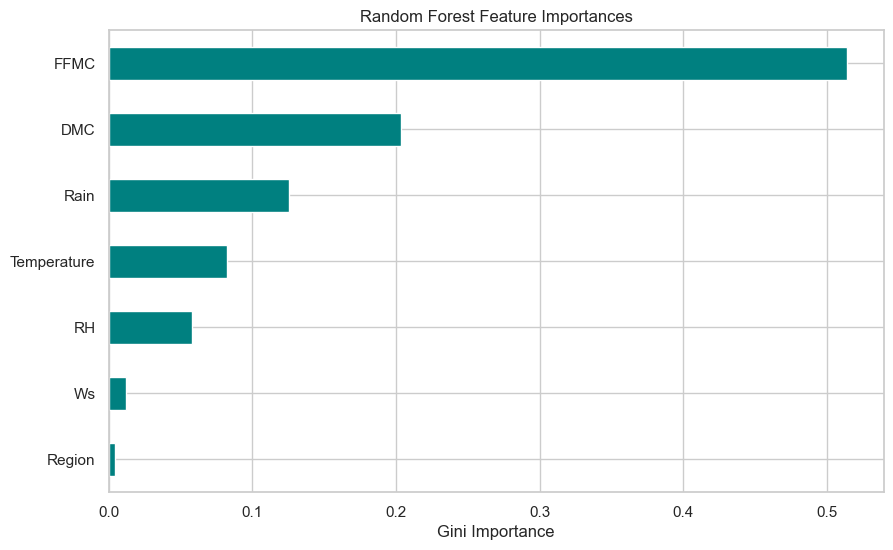

In [7]:
# Train a basic Random Forest to assess feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_selected, y_train)

# Extract and plot feature importances
importances = pd.Series(rf.feature_importances_, index=X_train_selected.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importances')
plt.xlabel('Gini Importance')
plt.show()

# All selected features show some level of importance, with FWI/FFMC being the most critical.

**Why this step is necessary:** 
While correlation removes redundancy, tree-based feature importance evaluates the actual predictive power of the remaining features regarding the target variable.

**Impact on model performance:** 
If any features had near-zero importance (e.g., `< 0.01`), we would drop them to further simplify the model. Here, all remaining features contribute meaningfully, so we will retain them all.

**Any assumptions made:** 
We assume that the Gini Importance derived from a Random Forest Classifier is a reliable proxy for global feature utility across other model architectures.

# Final Dataset Preparation

In [8]:
import os

# Save the final engineered datasets for the model training phase
X_train_selected.to_csv('../data/processed/X_train.csv', index=False)
X_test_selected.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Final feature-engineered datasets successfully saved to 'data/processed/'!")
print(f"Final Training Data Shape: {X_train_selected.shape}")

Final feature-engineered datasets successfully saved to 'data/processed/'!
Final Training Data Shape: (194, 7)


**Why this step is necessary:** 
Data serialization cleanly separates the Feature Engineering pipeline phase from the Model Training phase. 

**Impact on model performance:** 
It has no direct impact on model performance, but it has a massive impact on MLOps maintainability. It allows us to experiment with dozens of different models in the next notebook without re-running the entire engineering pipeline.

**Any assumptions made:** 
We assume that the `data/processed/` directory is persistent and accessible by the subsequent model training notebooks or scripts.